In [3]:
import numpy as np

import sys
import os
import warnings

warnings.simplefilter("ignore", FutureWarning)

In [12]:
from attack_training import optimize, theta_to_params

# Add the ability to import modules from the ocr/utils directory
sys.path.append(os.path.abspath("../utils"))

from google_vision import query_google_vision, predict_and_annotate
from image_tools import show_image, render_text


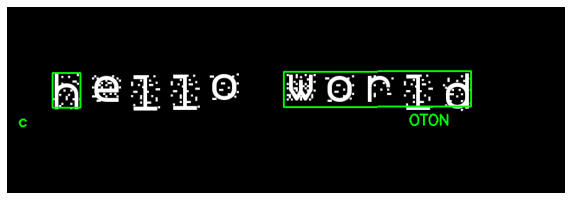

In [ ]:
p = {
    "per_char_rot_std": 1.0,
    "kerning_std": 1.0,
    "baseline_amp": 1.0,
    "baseline_freq": 1.0,
    "y_jitter_std": 1.0,
    "text_color": (255, 255, 255),
    "background_color": (0, 0, 0)
}

img = render_text("hello world", params=p)
show_image(predict_and_annotate(img))

In [8]:
def theta_to_params(theta):
    return {
        "per_char_rot_std": np.clip(abs(theta[0])*10, 0, 15),
        "kerning_std": np.clip(theta[1]*5, -10, 10),
        "baseline_amp": np.clip(theta[2]*10, 0, 20),
        "baseline_freq": np.clip(theta[3], 0.1, 1.0),
        "y_jitter_std": np.clip(theta[4]*5, 0, 10)
    }

In [6]:
theta = np.array([
    0.0,  # per_char_rot_std
    0.0,  # kerning_std
    0.0,  # baseline_amp
    0.0,  # baseline_freq
    0.0,  # y_jitter_std
])

In [10]:
test_labels = ['hello world', 'hamburger', 'computer and data']

theta = optimize(theta,
                 test_labels,
                 query_function=query_google_vision,
                 steps=10,
                 sigma=2,
                 lr=0.1,
                 n_samples=20
                )

print(theta)

Step 000 | Loss: 2.2681
Step 001 | Loss: 2.0782
Step 002 | Loss: 2.1960
Step 003 | Loss: 2.3164
Step 004 | Loss: 2.3626
Step 005 | Loss: 2.1689
Step 006 | Loss: 2.4584
Step 007 | Loss: 2.2784
Step 008 | Loss: 2.4341
Step 009 | Loss: 2.3394
[ 0.03289485 -0.01652096  0.00593485 -0.00499186  0.00987799]


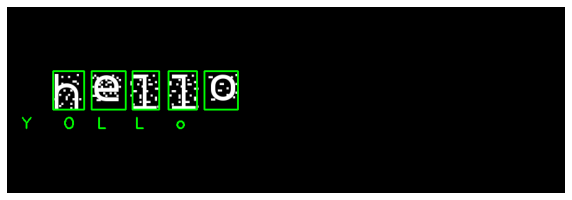

In [ ]:
img = render_text("hello world", params=theta_to_params(theta))
show_image(predict_and_annotate(img))